# W4 — Outliers, Noise & Consistency 🌦️
## Dự án dự báo thời tiết Hà Nội — NASA POWER
**Mục tiêu:** kiểm tra tính nhất quán; phát hiện ngoại lệ bằng Z-score, Modified Z-score, IQR và phương pháp đa biến; phân biệt lỗi với thời tiết hiếm; thử nghiệm cách xử lý và xuất nhật ký.

Notebook dùng đúng schema CSV raw trong dự án. Nội dung được triển khai theo các chủ đề W4.pdf (trang 5–31); các ngưỡng thống kê và chính sách dưới đây là lựa chọn thực hành, không phải quy định bắt buộc của giảng viên.

**Cách chạy:** đặt file này vào `Weather-Prediction-ML/notebooks/`, chọn kernel của venv trong VS Code rồi **Run All**. Có thể đặt ở thư mục gốc dự án. Không sửa dữ liệu raw. Đầu ra nằm tại `data/cleaned/w4/` và `reports/w4/`.

Nếu thiếu thư viện, chạy ô cài đặt bên dưới bằng cách bỏ dấu `#`. Tên gói cài là `scikit-learn`, tên import là `sklearn`.

**Phiên bản W4 không chia tập:** toàn bộ dữ liệu được dùng để khám phá, tính ngưỡng và sàng lọc ngoại lệ. Không huấn luyện hoặc đánh giá mô hình dự báo. Isolation Forest chỉ là phần mở rộng phát hiện bất thường.


In [1]:
# %pip install pandas numpy matplotlib scikit-learn ipykernel


### 1. Cấu hình và dữ liệu đầu vào
Một dòng là một giờ tại một điểm đại diện Hà Nội. Đây là dữ liệu NASA POWER, không tự coi là quan trắc tại một trạm vật lý.

| Biến | Ý nghĩa | Đơn vị theo từ điển dự án |
|---|---|---|
| T2M | Nhiệt độ ở độ cao 2 m | °C |
| PRECTOTCORR | Lượng mưa hiệu chỉnh theo giờ | mm/giờ |
| RH2M | Độ ẩm tương đối ở 2 m | % |
| PS | Áp suất bề mặt | kPa |
| WS2M | Tốc độ gió ở 2 m | m/s |
| WD2M | Hướng gió ở 2 m | độ |
| ALLSKY_SFC_SW_DWN | Bức xạ sóng ngắn đi xuống bề mặt | Wh/m² |

`WD2M` là biến vòng tròn: 359° gần 0°. Không áp dụng trực tiếp Z-score/IQR tuyến tính cho hướng gió. Tọa độ và cột định danh cũng không đưa vào bộ phát hiện ngoại lệ.


In [2]:
from pathlib import Path
from datetime import timezone, timedelta
import json, hashlib, unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.rcParams.update({'figure.figsize': (12, 4), 'axes.grid': True, 'grid.alpha': .2})
pd.set_option('display.max_columns', 20)
# Nếu dữ liệu ở nơi khác, gán đường dẫn tuyệt đối cho INPUT_OVERRIDE.
INPUT_OVERRIDE = None  # Ví dụ: Path(r'C:\Users\ameli\Weather-Prediction-ML\data\raw\nasa_power\hanoi_hourly_20230101_20241231.csv')
RELATIVE_INPUT = Path('data/raw/nasa_power/hanoi_hourly_20230101_20241231.csv')
if INPUT_OVERRIDE is None:
    candidates = [Path.cwd(), *Path.cwd().parents]
    ROOT = next((p for p in candidates if (p / RELATIVE_INPUT).exists()), None)
    if ROOT is None:
        raise FileNotFoundError('Đặt notebook vào thư mục gốc/notebooks của dự án hoặc sửa INPUT_OVERRIDE.')
    INPUT = ROOT / RELATIVE_INPUT
else:
    INPUT = Path(INPUT_OVERRIDE).expanduser().resolve()
    ROOT = Path.cwd()
REPORT_DIR = ROOT / 'reports/w4'
OUTPUT_DIR = ROOT / 'data/cleaned/w4'
FEATURES = ['T2M','PRECTOTCORR','RH2M','PS','WS2M','WD2M','ALLSKY_SFC_SW_DWN']
LINEAR = [c for c in FEATURES if c != 'WD2M']
VN_TZ = timezone(timedelta(hours=7))
raw = pd.read_csv(INPUT)
required = ['timestamp','city','latitude','longitude', *FEATURES]
assert set(required).issubset(raw.columns), 'CSV không đúng schema dự án.'
SOURCE_SHA256 = hashlib.sha256(INPUT.read_bytes()).hexdigest()
print('Input:', INPUT)
print('Kích thước:', raw.shape)
display(raw.head())


,timestamp,city,latitude,longitude,T2M,PRECTOTCORR,RH2M,PS,WS2M,WD2M,ALLSKY_SFC_SW_DWN
0,2023-01-01T00:00:00Z,Hanoi,21.0285,105.8542,9.75,0.0,83.01,101.62,2.13,17.8,117.28
1,2023-01-01T01:00:00Z,Hanoi,21.0285,105.8542,12.01,0.0,71.80,101.66,2.76,30.0,298.23
2,2023-01-01T02:00:00Z,Hanoi,21.0285,105.8542,14.32,0.0,64.32,101.66,2.79,40.5,474.75
3,2023-01-01T03:00:00Z,Hanoi,21.0285,105.8542,16.32,0.0,60.20,101.60,2.31,41.5,616.85
4,2023-01-01T04:00:00Z,Hanoi,21.0285,105.8542,17.81,0.0,58.20,101.48,1.95,39.8,649.58


Input: /workspace/scratch/91d7a37c0b6d/project/Weather-Prediction-ML/data/raw/nasa_power/hanoi_hourly_20230101_20241231.csv
Kích thước: (17544, 11)


### 2. Kiểm tra tổng quan và tính nhất quán
Kiểm tra dtype, thiếu, unique, duplicate, ngày giờ, địa điểm và các bước giờ bị thiếu. Khóa dữ liệu là địa điểm + thời điểm. Không gộp trung bình những bản ghi trùng khóa nhưng có giá trị khác nhau.

Chỉ chuẩn hóa các quy tắc đã biết: khoảng trắng/Unicode tên thành phố, kiểu số, thời gian UTC → GMT+7, hướng gió 360° → 0°. Không tự suy đoán một giá trị áp suất là hPa chỉ vì nó quá lớn.

**Mục đích bảng thống kê:** `25%` là Q1, `50%` là trung vị, `75%` là Q3. Khoảng Q1–Q3 chứa phần giữa 50% quan sát; IQR = Q3 − Q1 sẽ được dùng để tạo ngưỡng sàng lọc ở mục 6. `describe()` ở đây chỉ hiển thị, chưa đánh dấu hoặc sửa outlier. Thống kê mean/phân vị của WD2M nếu xuất hiện không dùng để suy luận hướng gió vì đây là biến vòng tròn.

`audit = []` tạo danh sách nhật ký; `def log(...)` định nghĩa hàm ghi nhật ký. Chỉ những lần gọi `log(...)` mới thêm bản ghi. Dữ liệu đang được sửa trong bản sao `work`; cell này chưa ghi file.


In [3]:
overview = pd.DataFrame({'dtype':raw.dtypes.astype(str), 'missing':raw.isna().sum(),
                         'unique':raw.nunique(dropna=True)})
display(overview)
# Chỉ thống kê các biến tuyến tính; hướng gió được kiểm tra miền riêng.
# Q1/Q3 mô tả vùng tập trung, chưa dùng để tự động xóa điểm.
display(raw[LINEAR].describe().T)
print('Dòng trùng hoàn toàn:', raw.duplicated().sum())
work = raw.copy()
work['source_row'] = np.arange(1, len(work) + 1)
audit = []
def log(mask, column, before, after, reason, action):
    for i in work.index[mask]:
        audit.append({'source_row':int(work.at[i,'source_row']), 'column':column,
                      'before':str(before.loc[i]),
                      'after':str(after.loc[i] if isinstance(after,pd.Series) else after),
                      'reason':reason, 'action':action})

city_before = work['city'].copy()
work['city'] = work['city'].astype('string').map(lambda x: unicodedata.normalize('NFC',x).strip() if pd.notna(x) else x)
log(city_before.ne(work.city).fillna(False), 'city', city_before, work.city, 'Unicode/khoảng trắng', 'normalize')
work['timestamp'] = pd.to_datetime(work['timestamp'], utc=True, errors='coerce')
if work.timestamp.isna().any():
    display(work.loc[work.timestamp.isna()])
    raise ValueError('Có ngày giờ không đọc được; cần sửa nguồn trước khi tiếp tục.')
assert ((work.timestamp.dt.minute == 0) & (work.timestamp.dt.second == 0) & (work.timestamp.dt.microsecond == 0)).all(), 'Thời điểm không tròn giờ.'
for c, expected in [('latitude',21.0285),('longitude',105.8542)]:
    work[c] = pd.to_numeric(work[c], errors='coerce')
    assert np.isclose(work[c],expected,atol=1e-6,rtol=0).all(), f'Sai vị trí: {c}'
assert work.city.eq('Hanoi').all(), 'Notebook này chỉ cấu hình cho Hanoi.'

fill_values = {-999.0}
meta_path = INPUT.with_suffix('.metadata.json')
if meta_path.exists():
    source_meta = json.loads(meta_path.read_text(encoding='utf-8'))
    for source in source_meta.get('sources', []):
        if source.get('fill_value') is not None:
            fill_values.add(float(source['fill_value']))
for c in FEATURES:
    old = work[c].copy()
    numeric = pd.to_numeric(old, errors='coerce')
    bad = numeric.isna() | ~np.isfinite(numeric) | numeric.isin(fill_values)
    log(bad & old.notna(), c, old, np.nan, 'Không phải số hữu hạn / mã thiếu', 'set_nan')
    work[c] = numeric.mask(bad)

keys = ['city','latitude','longitude','timestamp']
dup = work.duplicated(keys, keep=False)
conflicts = work.loc[dup].groupby(keys)[FEATURES].nunique(dropna=False).gt(1).any(axis=1)
if conflicts.any():
    display(conflicts[conflicts])
    raise ValueError('Trùng khóa có giá trị mâu thuẫn: cần điều tra, không tự chọn một dòng.')
drop = work.duplicated(keys, keep='first')
log(drop, 'row', work.source_row, 'removed', 'Trùng khóa, cùng giá trị khí tượng sau chuẩn hóa', 'drop_duplicate')
work = work.loc[~drop].sort_values('timestamp').reset_index(drop=True)
work['timestamp'] = work.timestamp.dt.tz_convert(VN_TZ)
expected_hours = pd.date_range(work.timestamp.min(), work.timestamp.max(), freq='h')
missing_hours = expected_hours.difference(pd.DatetimeIndex(work.timestamp))
print('Khoảng thời gian địa phương:', work.timestamp.min(), '→', work.timestamp.max())
print('Số giờ thiếu:', len(missing_hours))
display(pd.DataFrame({'missing_timestamp':missing_hours}).head(20))


,dtype,missing,unique
timestamp,object,0,17544
city,object,0,1
latitude,float64,0,1
longitude,float64,0,1
T2M,float64,0,2853
PRECTOTCORR,float64,0,390
RH2M,float64,0,4730
PS,float64,0,414
WS2M,float64,0,587
WD2M,float64,0,3225


,count,mean,std,min,25%,50%,75%,max
T2M,17544.0,24.017949,6.107212,3.29,19.9400,25.290,28.1400,41.27
PRECTOTCORR,17544.0,0.202872,0.642197,0.00,0.0000,0.010,0.1400,19.05
RH2M,17544.0,82.887371,14.046427,27.57,72.4375,86.870,94.9925,100.00
PS,17544.0,100.086936,0.743264,97.42,99.4700,100.010,100.6400,102.40
WS2M,17544.0,1.746993,1.046237,0.01,0.9600,1.500,2.3400,11.64
ALLSKY_SFC_SW_DWN,17544.0,156.755786,228.680394,0.00,0.0000,5.365,264.4275,988.47


,missing_timestamp


Dòng trùng hoàn toàn: 0
Khoảng thời gian địa phương: 2023-01-01 07:00:00+07:00 → 2025-01-01 06:00:00+07:00
Số giờ thiếu: 0


### 3. Lỗi miền giá trị ≠ ngoại lệ thống kê
Các ràng buộc dưới đây chỉ bắt lỗi cơ bản: độ ẩm ngoài 0–100%, lượng mưa/tốc độ gió/bức xạ âm, áp suất không dương, nhiệt độ dưới độ không tuyệt đối, hướng gió ngoài 0–360°. Không dùng khoảng nhiệt độ “thường gặp” làm lý do xóa.

Ô vi phạm → NaN có nhật ký. Chưa điền thiếu trong W4. Với dự báo, việc điền thiếu phải dùng thông tin có sẵn tại thời điểm dự báo; không điền nhãn kiểm thử bằng nội suy.


In [4]:
invalid = pd.DataFrame(False, index=work.index, columns=FEATURES)
invalid['T2M'] = work.T2M < -273.15
invalid['RH2M'] = (work.RH2M < 0) | (work.RH2M > 100)
invalid['PS'] = work.PS <= 0
invalid['WD2M'] = (work.WD2M < 0) | (work.WD2M > 360)
for c in ['PRECTOTCORR','WS2M','ALLSKY_SFC_SW_DWN']:
    invalid[c] = work[c] < 0
for c in FEATURES:
    log(invalid[c], c, work[c].copy(), np.nan, 'Vi phạm miền giá trị cơ bản', 'set_nan')
    work.loc[invalid[c], c] = np.nan
wind360 = work.WD2M.eq(360)
log(wind360,'WD2M',work.WD2M.copy(),0,'360 độ tương đương 0 độ','normalize')
work.loc[wind360,'WD2M'] = 0.0
baseline = work.copy()
display(pd.DataFrame({'invalid_cells':invalid.sum(), 'missing_after_validation':work[FEATURES].isna().sum()}))


,invalid_cells,missing_after_validation
T2M,0,0
PRECTOTCORR,0,0
RH2M,0,0
PS,0,0
WS2M,0,0
WD2M,0,0
ALLSKY_SFC_SW_DWN,0,0


### 4. Phạm vi phân tích W4: toàn bộ dữ liệu
Notebook sử dụng tất cả các dòng sau kiểm tra cơ bản để tính thống kê và ngưỡng. Không tạo tập train/test và không tạo cột split. Kết quả mô tả dữ liệu lịch sử đang có, không phải đánh giá khả năng dự báo trên dữ liệu chưa thấy.

Khi chuyển sang giai đoạn xây dựng mô hình dự báo sau này, cần thiết kế lại bước ước lượng ngưỡng theo dữ liệu huấn luyện; không coi ngưỡng toàn bộ dữ liệu hiện tại là ngưỡng đã được kiểm định.


In [5]:
print('Phạm vi: toàn bộ dữ liệu W4')
print('Số dòng:', len(work))
print('Thời gian:', work.timestamp.min(), '→', work.timestamp.max())


Phạm vi: toàn bộ dữ liệu W4
Số dòng: 17544
Thời gian: 2023-01-01 07:00:00+07:00 → 2025-01-01 06:00:00+07:00


### 5. Quan sát phân bố và chuỗi thời gian
Histogram cho biết độ lệch và khối lượng điểm bằng 0; boxplot giúp xem phần đuôi; chuỗi thời gian giúp nhận diện thay đổi theo mùa và các đợt kéo dài. Biểu đồ này dùng tập toàn bộ dữ liệu.


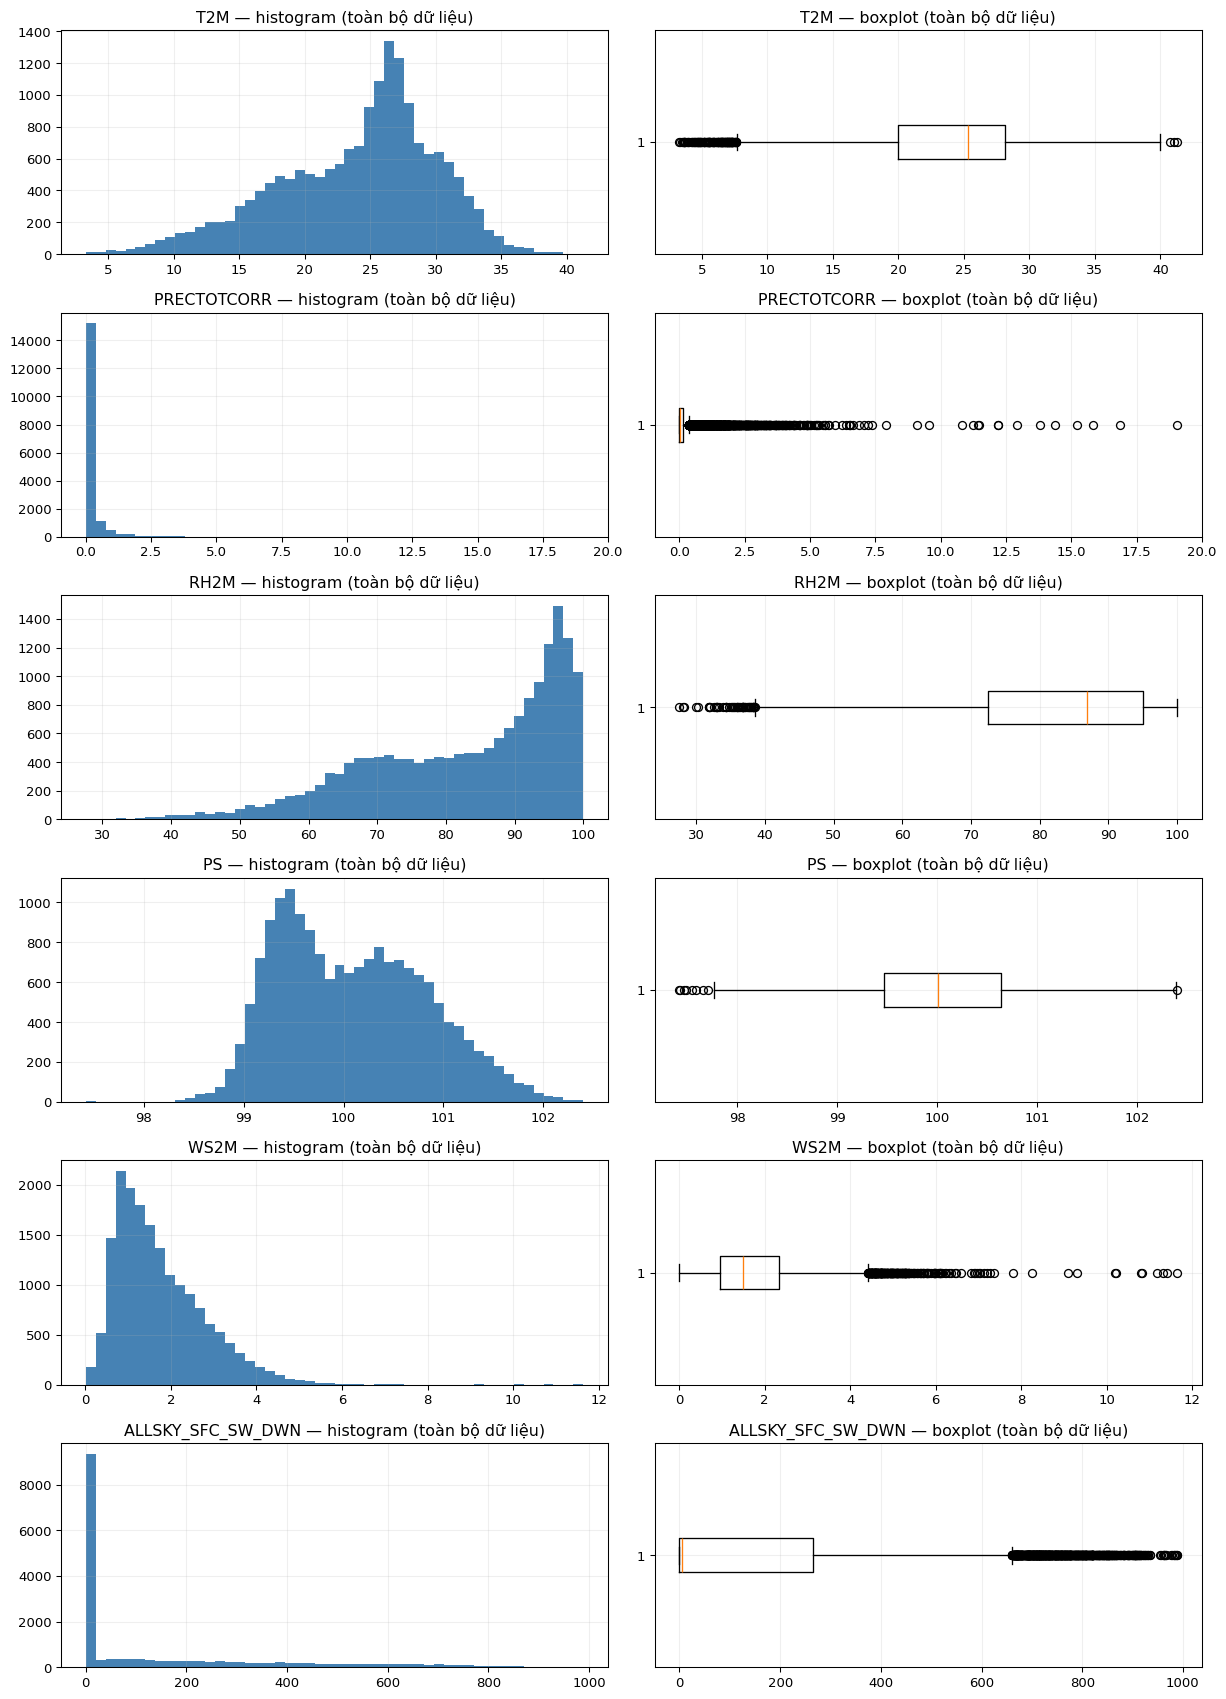

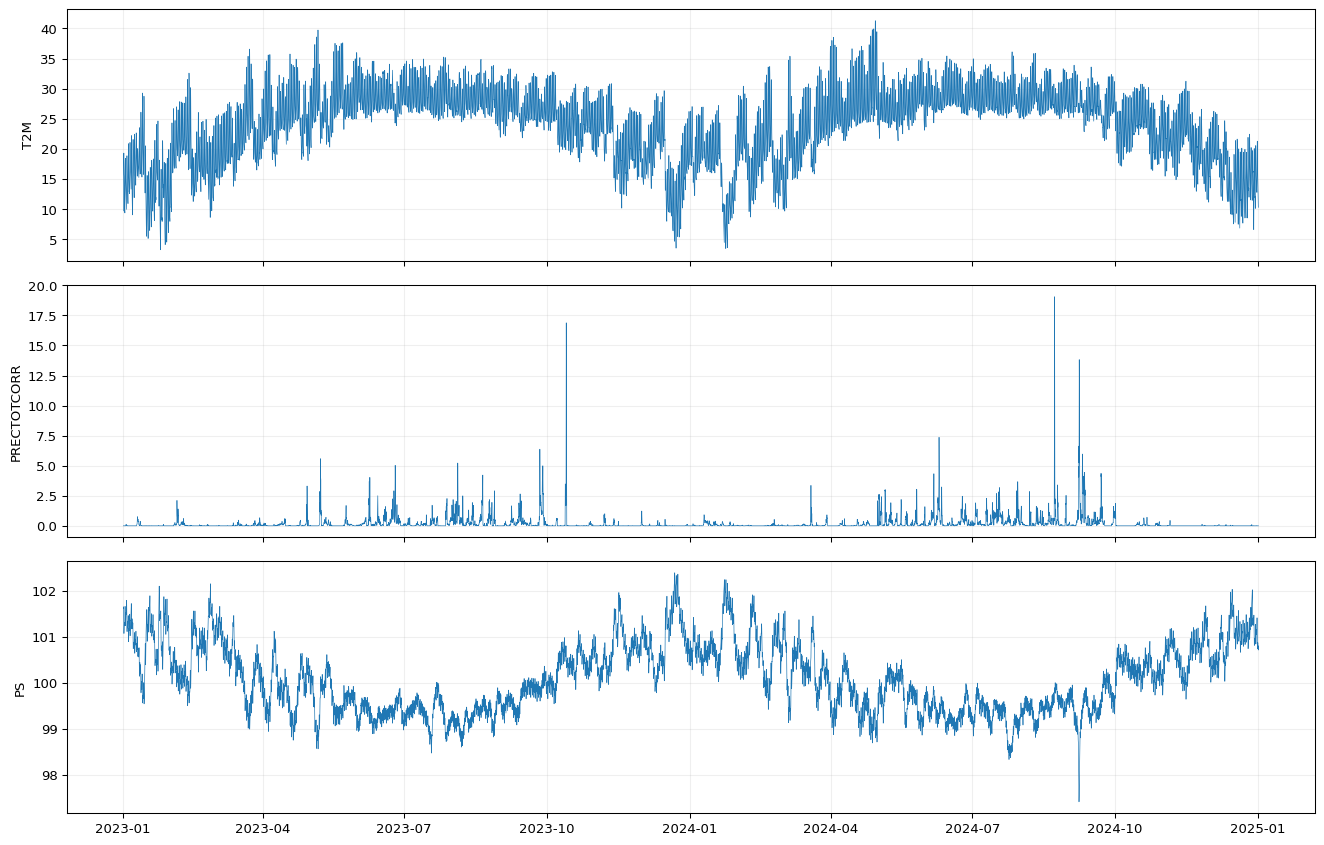

In [6]:
fig, axes = plt.subplots(len(LINEAR),2,figsize=(13,18))
for row,c in enumerate(LINEAR):
    values = work[c].dropna()
    axes[row,0].hist(values,bins=50,color='steelblue')
    axes[row,0].set_title(c + ' — histogram (toàn bộ dữ liệu)')
    axes[row,1].boxplot(values,vert=False)
    axes[row,1].set_title(c + ' — boxplot (toàn bộ dữ liệu)')
plt.tight_layout(); plt.show()
fig, axes = plt.subplots(3,1,figsize=(14,9),sharex=True)
for ax,c in zip(axes,['T2M','PRECTOTCORR','PS']):
    ax.plot(work.timestamp, work[c],lw=.5)
    ax.set_ylabel(c)
plt.tight_layout(); plt.show()


Các biến khí tượng có phân bố khác nhau; lượng mưa, tốc độ gió và bức xạ lệch phải, trong khi độ ẩm tập trung ở mức cao. Boxplot phát hiện nhiều điểm ngoài ngưỡng IQR, nhưng chưa đủ cơ sở coi chúng là lỗi. Cần kiểm tra thêm bối cảnh thời gian và tính hợp lý trước khi xử lý.

### 6. Z-score, Modified Z-score và IQR
- **Z-score:** \(z=(x-\mu)/\sigma\), gắn cờ khi \(|z|>3\). Nhạy với phân bố lệch và chính các điểm cực trị.
- **Modified Z-score:** \(M=0.6745(x-\mathrm{median})/MAD\), gắn cờ khi \(|M|>3.5\); MAD là trung vị độ lệch tuyệt đối.
- **IQR:** \(IQR=Q_3-Q_1\); gắn cờ ngoài \([Q_1-1.5IQR,Q_3+1.5IQR]\).

Nếu độ lệch chuẩn, MAD hoặc IQR bằng 0, phương pháp tương ứng trả trạng thái không áp dụng (`NA`), không tự chia cho 0 hay kết luận tất cả điểm khác 0 là sai. Lượng mưa và bức xạ có nhiều số 0 nên cần đặc biệt thận trọng. Các cờ này là **ứng viên điều tra**, không phải nhãn lỗi.

**Cách đọc kết quả:** `low`/`high` là ngưỡng IQR; `evaluated` là số ô đủ điều kiện đánh giá; `flagged` là số ô bị gắn cờ; `percent` = flagged/evaluated × 100. Ngưỡng tính trên toàn bộ dữ liệu hiện tại.


In [7]:
threshold_rows=[]
for c in LINEAR:
    s=work[c].dropna()
    q1,q3=s.quantile([.25,.75]); median=s.median()
    threshold_rows.append({'feature':c,'n':len(s),'mean':s.mean(),'std':s.std(ddof=0),
                           'median':median,'mad':(s-median).abs().median(),
                           'q1':q1,'q3':q3,'iqr':q3-q1,
                           'low':q1-1.5*(q3-q1),'high':q3+1.5*(q3-q1)})
thresholds=pd.DataFrame(threshold_rows).set_index('feature')
flags=pd.DataFrame(index=work.index)
summary=[]
for c in LINEAR:
    p=thresholds.loc[c]; s=work[c]
    conditions={
        'z': ((s-p['mean'])/p['std']).abs()>3 if p['std']>0 else None,
        'modified_z': (0.6745*(s-p['median'])/p['mad']).abs()>3.5 if p['mad']>0 else None,
        'iqr': ((s<p['low']) | (s>p['high'])) if p['iqr']>0 else None,
    }
    for method,condition in conditions.items():
        col=f'{c}__{method}'
        flags[col]=pd.Series(pd.NA,index=work.index,dtype='boolean')
        if condition is not None:
            flags.loc[s.notna(),col]=condition.loc[s.notna()]
        valid=flags[col].dropna()
        summary.append({'feature':c,'method':method,'evaluated':len(valid),
                        'flagged':int(valid.sum()),'percent':100*valid.mean() if len(valid) else np.nan})
summary=pd.DataFrame(summary)
display(thresholds.round(4))
display(summary.round(2))


,n,mean,std,median,mad,q1,q3,iqr,low,high
feature,,,,,,,,,,
T2M,17544,24.0179,6.1070,25.290,3.860,19.9400,28.1400,8.2000,7.6400,40.4400
PRECTOTCORR,17544,0.2029,0.6422,0.010,0.010,0.0000,0.1400,0.1400,-0.2100,0.3500
RH2M,17544,82.8874,14.0460,86.870,9.590,72.4375,94.9925,22.5550,38.6050,128.8250
PS,17544,100.0869,0.7432,100.010,0.580,99.4700,100.6400,1.1700,97.7150,102.3950
WS2M,17544,1.7470,1.0462,1.500,0.640,0.9600,2.3400,1.3800,-1.1100,4.4100
ALLSKY_SFC_SW_DWN,17544,156.7558,228.6739,5.365,5.365,0.0000,264.4275,264.4275,-396.6412,661.0688


,feature,method,evaluated,flagged,percent
0,T2M,z,17544,56,0.32
1,T2M,modified_z,17544,42,0.24
2,T2M,iqr,17544,136,0.78
3,PRECTOTCORR,z,17544,273,1.56
4,PRECTOTCORR,modified_z,17544,5879,33.51
5,PRECTOTCORR,iqr,17544,2514,14.33
6,RH2M,z,17544,95,0.54
7,RH2M,modified_z,17544,41,0.23
8,RH2M,iqr,17544,56,0.32
9,PS,z,17544,18,0.10


### 7. Ngoại lệ theo ngữ cảnh: tháng và giờ địa phương
Nhiệt độ 30°C có ý nghĩa khác nhau giữa các mùa; bức xạ cao vào buổi trưa có thể bình thường. So sánh mỗi điểm với nhóm **cùng tháng, cùng giờ** trong toàn bộ dữ liệu bằng IQR. Cần ít nhất 20 quan sát hợp lệ/nhóm và IQR > 0; nhóm thiếu hỗ trợ trả NA, không suy diễn “bình thường”. Hai năm tham chiếu vẫn hạn chế: kết quả chỉ hỗ trợ điều tra.


In [8]:
context_tables=[]
for c in ['T2M','RH2M','PS','ALLSKY_SFC_SW_DWN']:
    ref=work.assign(month=work.timestamp.dt.month,hour=work.timestamp.dt.hour)
    table=ref.groupby(['month','hour'])[c].agg(n='count',q1=lambda s:s.quantile(.25),q3=lambda s:s.quantile(.75))
    table['iqr']=table.q3-table.q1
    table['low']=table.q1-1.5*table.iqr; table['high']=table.q3+1.5*table.iqr
    context_tables.append(table.reset_index().assign(feature=c))
    idx=pd.MultiIndex.from_arrays([work.timestamp.dt.month,work.timestamp.dt.hour],names=['month','hour'])
    bounds=table.reindex(idx).reset_index(drop=True)
    eligible=work[c].notna() & bounds.n.ge(20) & bounds.iqr.gt(0)
    name=c+'__context_iqr'
    flags[name]=pd.Series(pd.NA,index=work.index,dtype='boolean')
    flags.loc[eligible,name]=((work[c]<bounds.low)|(work[c]>bounds.high)).loc[eligible]
context_thresholds=pd.concat(context_tables,ignore_index=True)
display(flags.filter(like='context').agg(['count','sum']).T)


,count,sum
T2M__context_iqr,17544,210
RH2M__context_iqr,17544,516
PS__context_iqr,17544,128
ALLSKY_SFC_SW_DWN__context_iqr,9202,173


### 8. Nhiễu và biến động bất thường theo thời gian
Dùng chênh lệch giữa **hai giờ liên tiếp** để tìm thay đổi đột ngột. Bỏ qua cặp cách nhau hơn một giờ; với hướng gió dùng khoảng cách góc ngắn nhất. Ngưỡng minh họa là phân vị 99.5% của độ thay đổi trong toàn bộ dữ liệu, không phải giới hạn khí tượng.

Đường trung vị 6 giờ trước chỉ dùng minh họa làm mượt; không ghi đè quan trắc. Làm mượt có thể làm mất đỉnh mưa/gió thật. Ngoại lệ tập thể là cả một chuỗi đáng ngờ: những đoạn liên tiếp được liệt kê để xem xét, không tự kết luận là hỏng cảm biến.


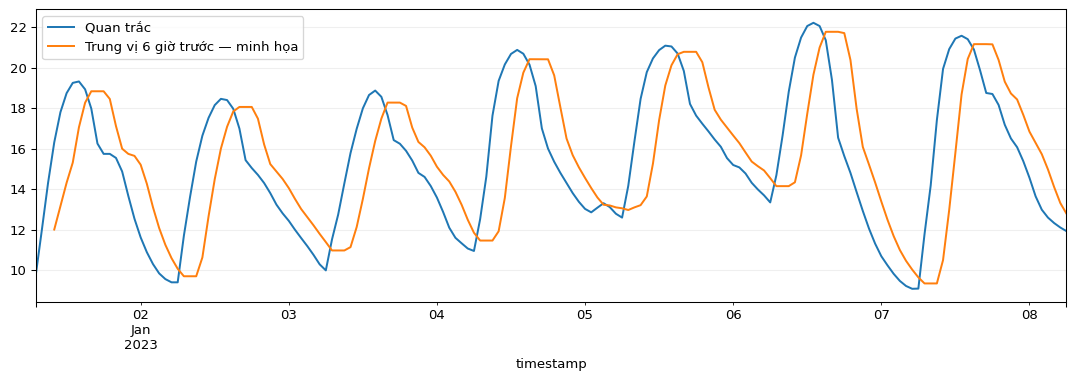

,all_data_abs_change_p99_5
T2M,3.0200
PRECTOTCORR,1.1200
RH2M,15.4187
PS,0.1600
WS2M,1.1529
WD2M,98.5510
ALLSKY_SFC_SW_DWN,232.5148


In [9]:
adjacent=work.timestamp.diff().eq(pd.Timedelta(hours=1))
jump_thresholds={}
for c in FEATURES:
    delta=work[c].diff()
    if c=='WD2M': delta=(delta+180)%360-180
    delta=delta.abs().where(adjacent)
    limit=delta.quantile(.995)
    jump_thresholds[c]=float(limit)
    col=c+'__jump'
    flags[col]=pd.Series(pd.NA,index=work.index,dtype='boolean')
    if pd.notna(limit):
        flags.loc[delta.notna(),col]=delta.loc[delta.notna()]>limit
series=work.set_index('timestamp').T2M
smooth=series.rolling('6h',closed='left',min_periods=3).median()
fig,ax=plt.subplots(figsize=(14,4))
series.iloc[:168].plot(ax=ax,label='Quan trắc')
smooth.iloc[:168].plot(ax=ax,label='Trung vị 6 giờ trước — minh họa')
ax.legend(); plt.show()
display(pd.Series(jump_thresholds,name='all_data_abs_change_p99_5').to_frame())


### 9. Ngoại lệ đa biến — Isolation Forest
Một điểm có thể hợp lý ở từng cột nhưng bất thường khi xét tổ hợp các cột. Mã hóa hướng gió bằng sin/cos, dùng `log1p` cho mưa và bức xạ rồi fit bộ phát hiện trên toàn bộ dữ liệu. Chỉ dùng hàng đầy đủ để không trộn tác động của điền thiếu.

`contamination=0.01` là giả định thử nghiệm đặt ngưỡng điểm số theo khoảng 1% toàn bộ dữ liệu; không chứng minh 1% dữ liệu là sai. Mô hình thiếu bối cảnh khí tượng vẫn có thể gắn cờ thời tiết thật. Mục này có thể bỏ qua nếu chưa cài scikit-learn.


In [10]:
iforest_available=False
try:
    from sklearn.ensemble import IsolationForest
    X=work[LINEAR].copy()
    for c in ['PRECTOTCORR','ALLSKY_SFC_SW_DWN']:
        X[c]=np.log1p(X[c])
    X['wind_sin']=np.sin(np.deg2rad(work.WD2M))
    X['wind_cos']=np.cos(np.deg2rad(work.WD2M))
    complete=X.notna().all(axis=1)
    if (complete).sum() >= 100:
        detector=IsolationForest(n_estimators=150,contamination=.01,random_state=42,n_jobs=-1)
        detector.fit(X.loc[complete])
        flags['multivariate__iforest']=pd.Series(pd.NA,index=work.index,dtype='boolean')
        flags.loc[complete,'multivariate__iforest']=detector.predict(X.loc[complete]) == -1
        iforest_available=True
        print('Số điểm đa biến cần xem xét:',int(flags['multivariate__iforest'].sum()))
    else:
        print('Không đủ 100 hàng work đầy đủ để fit.')
except ImportError:
    print('Bỏ qua mục 9: cài scikit-learn để chạy phần mở rộng.')


Số điểm đa biến cần xem xét: 176


### 10. Danh sách điểm cần điều tra và ngữ cảnh xung quanh
Các phương pháp không độc lập; nhiều cờ đồng thời không đồng nghĩa chắc chắn sai. Đối chiếu mưa–ẩm–gió–áp suất, giờ/ngày, các điểm lân cận và nguồn gốc trước khi ra quyết định.


,source_row,timestamp,T2M,PRECTOTCORR,RH2M,PS,WS2M,WD2M,ALLSKY_SFC_SW_DWN,flag_count,methods
14768,14769,2024-09-07 15:00:00+07:00,27.62,5.74,89.16,97.59,11.32,339.5,47.70,12,PRECTOTCORR__z|PRECTOTCORR__modified_z|PRECTOT...
14767,14768,2024-09-07 14:00:00+07:00,27.56,4.37,87.63,97.71,11.64,334.7,71.50,12,PRECTOTCORR__z|PRECTOTCORR__modified_z|PRECTOT...
14774,14775,2024-09-07 21:00:00+07:00,26.56,13.82,95.48,97.66,6.45,56.4,0.00,11,PRECTOTCORR__z|PRECTOTCORR__modified_z|PRECTOT...
14773,14774,2024-09-07 20:00:00+07:00,26.70,12.21,94.63,97.55,7.01,39.2,0.00,11,PRECTOTCORR__z|PRECTOTCORR__modified_z|PRECTOT...
14772,14773,2024-09-07 19:00:00+07:00,26.84,11.24,93.83,97.47,8.24,21.0,0.00,11,PRECTOTCORR__z|PRECTOTCORR__modified_z|PRECTOT...
14770,14771,2024-09-07 17:00:00+07:00,27.33,6.24,92.09,97.42,10.19,355.9,9.12,10,PRECTOTCORR__z|PRECTOTCORR__modified_z|PRECTOT...
14764,14765,2024-09-07 11:00:00+07:00,27.09,4.92,85.36,98.27,10.83,326.7,93.55,10,PRECTOTCORR__z|PRECTOTCORR__modified_z|PRECTOT...
2837,2838,2023-04-29 12:00:00+07:00,23.07,1.38,69.24,100.40,4.92,20.8,708.92,10,PRECTOTCORR__modified_z|PRECTOTCORR__iqr|WS2M_...
14771,14772,2024-09-07 18:00:00+07:00,27.05,5.23,93.11,97.43,9.31,6.4,0.00,10,PRECTOTCORR__z|PRECTOTCORR__modified_z|PRECTOT...
14766,14767,2024-09-07 13:00:00+07:00,27.35,4.05,87.03,97.89,11.41,332.6,101.03,10,PRECTOTCORR__z|PRECTOTCORR__modified_z|PRECTOT...


,timestamp,T2M,PRECTOTCORR,RH2M,PS,WS2M,WD2M,ALLSKY_SFC_SW_DWN
14765,2024-09-07 12:00:00+07:00,27.25,4.88,86.12,98.10,11.17,330.4,88.62
14766,2024-09-07 13:00:00+07:00,27.35,4.05,87.03,97.89,11.41,332.6,101.03
14767,2024-09-07 14:00:00+07:00,27.56,4.37,87.63,97.71,11.64,334.7,71.50
14768,2024-09-07 15:00:00+07:00,27.62,5.74,89.16,97.59,11.32,339.5,47.70
14769,2024-09-07 16:00:00+07:00,27.55,6.63,90.77,97.49,10.80,348.1,28.12
14770,2024-09-07 17:00:00+07:00,27.33,6.24,92.09,97.42,10.19,355.9,9.12
14771,2024-09-07 18:00:00+07:00,27.05,5.23,93.11,97.43,9.31,6.4,0.00


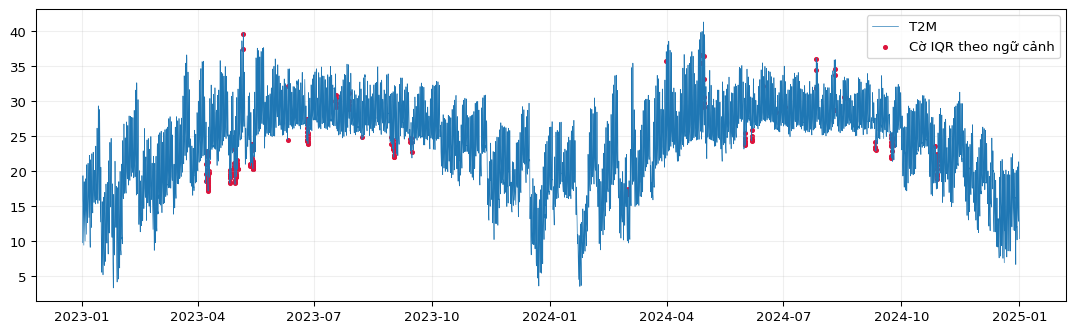

,start,end,hours
run,,,
1,2023-01-01 07:00:00+07:00,2023-01-01 16:00:00+07:00,10
5,2023-01-02 07:00:00+07:00,2023-01-02 16:00:00+07:00,10
7,2023-01-02 23:00:00+07:00,2023-01-03 03:00:00+07:00,5
9,2023-01-03 07:00:00+07:00,2023-01-03 16:00:00+07:00,10
11,2023-01-04 07:00:00+07:00,2023-01-04 16:00:00+07:00,10
15,2023-01-05 07:00:00+07:00,2023-01-05 16:00:00+07:00,10
17,2023-01-06 07:00:00+07:00,2023-01-06 16:00:00+07:00,10
19,2023-01-07 07:00:00+07:00,2023-01-07 16:00:00+07:00,10
23,2023-01-08 07:00:00+07:00,2023-01-08 16:00:00+07:00,10


In [11]:
votes=flags.fillna(False).astype(int).sum(axis=1)
review=work[['source_row','timestamp',*FEATURES]].copy()
review['flag_count']=votes
review['methods']=flags.fillna(False).apply(lambda row:'|'.join(row.index[row.to_numpy(dtype=bool)]),axis=1)
review=review.loc[votes>0].sort_values('flag_count',ascending=False)
display(review.head(20))
if not review.empty:
    i=review.index[0]
    display(work.loc[max(0,i-3):i+3,['timestamp',*FEATURES]])
    fig,ax=plt.subplots(figsize=(14,4))
    ax.plot(work.timestamp,work.T2M,lw=.5,label='T2M')
    mask=flags['T2M__context_iqr'].fillna(False)
    ax.scatter(work.loc[mask,'timestamp'],work.loc[mask,'T2M'],s=8,c='crimson',label='Cờ IQR theo ngữ cảnh')
    ax.legend(); plt.show()
# Đoạn có ít nhất 3 giờ liên tiếp mang một hay nhiều cờ: gợi ý rà soát tập thể.
active=votes.gt(0)
run=(active.ne(active.shift()) | ~adjacent).cumsum()
episodes=work.assign(active=active,run=run).loc[active].groupby('run').agg(start=('timestamp','min'),end=('timestamp','max'),hours=('timestamp','size'))
episodes=episodes.loc[episodes.hours>=3]
display(episodes.head(20))


### 11. Lựa chọn xử lý và thử nghiệm Winsorizing
| Trường hợp | Chính sách mặc định |
|---|---|
| Vi phạm miền giá trị / mã thiếu | Chuyển NaN, ghi nhật ký; xử lý thiếu riêng |
| Bản ghi trùng khóa, cùng giá trị | Giữ một bản ghi, ghi dòng đã loại |
| Bản ghi trùng khóa, mâu thuẫn | Dừng để điều tra |
| Cờ thống kê hoặc đa biến | Giữ nguyên, xuất danh sách cần kiểm tra |
| Thời tiết cực đoan được xác nhận hợp lệ | Giữ nguyên |

**Thử nghiệm**: chặn đuôi 1%–99% cho T2M, PS và WS2M, ngưỡng lấy từ toàn bộ dữ liệu. So sánh trước/sau để thấy tác động; không xuất bản thử nghiệm thành dữ liệu sạch mặc định. Không tùy tiện chặn mưa, vì có thể phá hủy tín hiệu mưa lớn. `log1p` giảm độ lệch nhưng cũng không chứng minh điểm dữ liệu đúng/sai.


,low,high
T2M,8.1558,35.3457
PS,98.7843,101.8400
WS2M,0.2500,4.7857


,feature,changed,mean_before,mean_after,max_before,max_after,std_before,std_after
0,T2M,352,24.018,24.020,41.27,35.346,6.107,6.022
1,PS,350,100.087,100.088,102.40,101.840,0.743,0.734
2,WS2M,350,1.747,1.738,11.64,4.786,1.046,1.003


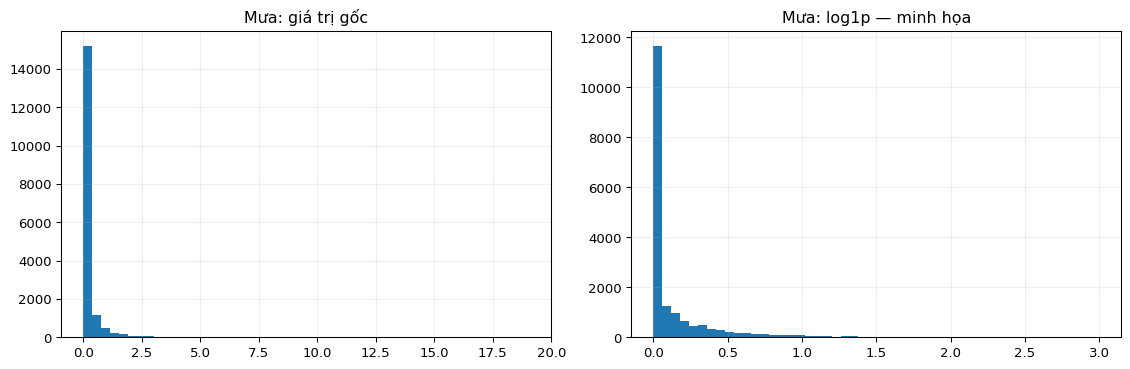

In [12]:
experiment=work.copy()
clip_bounds=work[['T2M','PS','WS2M']].quantile([.01,.99]).T
clip_bounds.columns=['low','high']
impact=[]
for c in clip_bounds.index:
    experiment[c]=work[c].clip(clip_bounds.at[c,'low'],clip_bounds.at[c,'high'])
    before=work[c]; after=experiment[c]
    impact.append({'feature':c,'changed':int((before.notna() & before.ne(after)).sum()),
                   'mean_before':before.mean(),'mean_after':after.mean(),
                   'max_before':before.max(),'max_after':after.max(),
                   'std_before':before.std(),'std_after':after.std()})
impact=pd.DataFrame(impact)
display(clip_bounds)
display(impact.round(3))
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].hist(work.PRECTOTCORR.dropna(),bins=50); axes[0].set_title('Mưa: giá trị gốc')
axes[1].hist(np.log1p(work.PRECTOTCORR.dropna()),bins=50); axes[1].set_title('Mưa: log1p — minh họa')
plt.tight_layout(); plt.show()


### 12. Xuất dữ liệu, cờ và nhật ký
`weather_w4_validated.csv` chỉ gồm các sửa đổi xác định ở phần 2–3 và các cột truy vết. Các giá trị chỉ bị gắn cờ thống kê vẫn giữ nguyên. File này **không bảo đảm không còn lỗi/NaN**, chưa phải bộ dữ liệu sẵn sàng huấn luyện.

Các tệp phụ: ngưỡng toàn bộ dữ liệu; cờ từng phương pháp (ô trống = không đánh giá được); danh sách cần điều tra; nhật ký thay đổi; giờ thiếu; thử nghiệm winsorizing và metadata. Các lần Run All sẽ ghi đè các đầu ra W4 cùng tên, không ghi đè CSV raw hoặc dữ liệu cleaned cũ của dự án.


In [13]:
assert hashlib.sha256(INPUT.read_bytes()).hexdigest()==SOURCE_SHA256, 'File raw bị thay đổi.'
assert not work.duplicated(['city','latitude','longitude','timestamp']).any()
assert work.timestamp.is_monotonic_increasing
# Chứng minh việc gắn cờ và thử nghiệm không sửa các phép đo mặc định.
pd.testing.assert_frame_equal(work[FEATURES],baseline[FEATURES])
REPORT_DIR.mkdir(parents=True,exist_ok=True)
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
work.to_csv(OUTPUT_DIR/'weather_w4_validated.csv',index=False,encoding='utf-8-sig')
flag_output=pd.concat([work[['source_row','timestamp']],flags],axis=1)
flag_output.to_csv(REPORT_DIR/'outlier_flags.csv',index=False)
review.to_csv(REPORT_DIR/'review_candidates.csv',index=False,encoding='utf-8-sig')
log_df=pd.DataFrame(audit,columns=['source_row','column','before','after','reason','action'])
log_df.to_csv(REPORT_DIR/'cleaning_log.csv',index=False,encoding='utf-8-sig')
thresholds.to_csv(REPORT_DIR/'all_data_thresholds.csv')
context_thresholds.to_csv(REPORT_DIR/'context_thresholds.csv',index=False)
summary.to_csv(REPORT_DIR/'method_comparison.csv',index=False)
impact.to_csv(REPORT_DIR/'winsorizing_impact.csv',index=False)
pd.DataFrame({'missing_timestamp':missing_hours}).to_csv(REPORT_DIR/'missing_hours.csv',index=False)
episodes.to_csv(REPORT_DIR/'flagged_episodes.csv',index=False)
metadata={'source_file':INPUT.name,'source_sha256':SOURCE_SHA256,'rows_raw':len(raw),
          'rows_output':len(work),'analysis_scope':'all_data_no_split','timezone_output':'UTC+07:00',
          'invalid_domain_cells':int(invalid.sum().sum()),'review_rows':len(review),
          'missing_hours':len(missing_hours),'missing_cells':int(work[FEATURES].isna().sum().sum()),
          'iforest_available':iforest_available,'jump_thresholds':jump_thresholds,
          'policy':'Statistical flags retained; no statistical clipping or imputation in validated output.'}
(REPORT_DIR/'metadata.json').write_text(json.dumps(metadata,ensure_ascii=False,indent=2),encoding='utf-8')
print('Dữ liệu:',OUTPUT_DIR/'weather_w4_validated.csv')
print('Báo cáo:',REPORT_DIR)
print('Số dòng cần xem xét:',len(review),'/',len(work))
print('Số thao tác trong nhật ký:',len(log_df))
display(log_df.head(20))


,source_row,column,before,after,reason,action


Dữ liệu: /workspace/scratch/91d7a37c0b6d/project/Weather-Prediction-ML/data/cleaned/w4/weather_w4_validated.csv
Báo cáo: /workspace/scratch/91d7a37c0b6d/project/Weather-Prediction-ML/reports/w4
Số dòng cần xem xét: 11720 / 17544
Số thao tác trong nhật ký: 0


### 13. Kết luận tự động và câu hỏi cho báo cáo W4
Kết quả dưới đây được tính từ lần chạy hiện tại. “Bị gắn cờ” không có nghĩa là “sai”. Nếu không phát hiện lỗi miền giá trị, hãy báo cáo đúng kết quả, không tạo lỗi giả để có nội dung làm sạch.


In [14]:
display(Markdown(f"""**Kết quả W4**
- Dữ liệu gốc: **{len(raw):,} dòng**, sau chuẩn hóa/loại trùng: **{len(work):,} dòng**.
- Ô vi phạm miền cơ bản: **{int(invalid.sum().sum()):,}**; ô thiếu còn lại: **{int(work[FEATURES].isna().sum().sum()):,}**.
- Giờ thiếu trong khoảng thời gian quan sát: **{len(missing_hours):,}**.
- Dòng có ít nhất một cờ cần xem xét: **{len(review):,}** (**{100*len(review)/len(work):.2f}%**).
- **Giữ nguyên ngoại lệ thống kê**; không áp dụng winsorizing cho dữ liệu đầu ra chính.
- Tất cả ngưỡng được tính từ toàn bộ dữ liệu W4, không chia tập.
"""))


**Kết quả W4**
- Dữ liệu gốc: **17,544 dòng**, sau chuẩn hóa/loại trùng: **17,544 dòng**.
- Ô vi phạm miền cơ bản: **0**; ô thiếu còn lại: **0**.
- Giờ thiếu trong khoảng thời gian quan sát: **0**.
- Dòng có ít nhất một cờ cần xem xét: **11,720** (**66.80%**).
- **Giữ nguyên ngoại lệ thống kê**; không áp dụng winsorizing cho dữ liệu đầu ra chính.
- Tất cả ngưỡng được tính từ toàn bộ dữ liệu W4, không chia tập.


**Tự nhận xét trước khi nộp:**
1. Biến nào có nhiều cờ nhất? Điều này có liên quan phân bố lệch, nhiều số 0, mùa hay giờ trong ngày không?
2. So sánh cờ IQR toàn cục và IQR theo ngữ cảnh của T2M/bức xạ. Nêu một thời điểm cụ thể từ bảng kết quả.
3. Chọn 3–5 bản ghi nghi ngờ, xem các giờ lân cận và giải thích quyết định giữ/điều tra/sửa. Chỉ kết luận lỗi khi có chứng cứ.
4. Winsorizing đã đổi bao nhiêu điểm và làm giảm đỉnh/độ lệch chuẩn thế nào? Vì sao chưa dùng cho đầu ra chính?
5. Hạn chế: chỉ một điểm địa lý, hai năm tham chiếu; chưa đối chiếu nguồn khí tượng độc lập; bộ phát hiện không xác nhận được mọi ngoại lệ tập thể.

**Chuyển sang W5:** dùng dữ liệu đã kiểm tra để biến đổi/tích hợp và thiết kế đặc trưng; tiếp tục kiểm soát thời gian sẵn có của dữ liệu. Không dùng `source_row` hoặc toàn bộ cờ kiểm tra làm feature một cách mặc định.

Tỷ lệ gắn cờ cao có thể phản ánh phương pháp không phù hợp với phân bố (đặc biệt mưa/bức xạ có nhiều số 0), không chứng minh tỷ lệ lỗi dữ liệu cao.
